# Real surfacings vs. model predictions, per float

For every tracked float: its confirmed real surfacing positions (colored by
time), and every scored surfacing's per-model predicted position, joined to
the real position by a thin line so the error is visible at a glance -- the
same overlay `docs/map.html` draws for a single selected float
(`drawFloatOverlays`), here laid out for all floats at once.

Reuses the pipeline's own load functions (`src/float_store.py`) and its
model color palette (`src/web_export.py`) rather than re-deriving anything
from the raw parquet files directly.

Run `git pull` first so `data/store/*.parquet` reflects the latest scored
surfacings before running this notebook.

In [5]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import float_store, run, web_export

cfg = run._load_config()
run._build_globals(cfg)

# run.STORE_DIR comes straight from config.toml ("data/store", a relative
# path) and float_store.load_floats_db/load_error_db just check
# Path(store_dir).exists() with no fallback -- if this notebook's working
# directory isn't the repo root (e.g. Jupyter was launched from inside
# notebooks/), that relative path silently resolves to nothing and every
# load comes back empty with no error. Anchor it to the repo root instead,
# found from run.py's own file location rather than cwd.
PROJECT_ROOT = Path(run.__file__).resolve().parent.parent
STORE_DIR = PROJECT_ROOT / cfg["paths"]["store_dir"]
assert STORE_DIR.exists(), f"STORE_DIR not found at {STORE_DIR}"

MODEL_COLOR = web_export.MODEL_COLOR
MODEL_MARKER = {"cmems": "o", "fcoo": "s"}

In [6]:
floats_db = float_store.load_floats_db(STORE_DIR)
error_db = float_store.load_error_db(STORE_DIR)

# One row per scored surfacing per model, real + predicted position both
# present -- exactly what web_export._build_scoring_history draws lines
# from. Older rows saved before this schema existed have NaN real_lat and
# are dropped here, same as web_export does.
scoring = error_db.dropna(subset=["real_lat", "predicted_lat"]).copy()
scoring["t"] = pd.to_datetime(scoring["t"])

print(f"{len(floats_db)} floats loaded, {len(scoring)} scored surfacings with a real+predicted pair")

7 floats loaded, 21 scored surfacings with a real+predicted pair


## All floats, one panel each

- Dot color = surfacing time (each float has its own color scale -- floats
  were registered at different times and some are much older than others,
  so a shared scale would flatten most of them).
- Grey line = chronological path between a float's own real surfacings.
- Diamond/circle markers = each model's predicted position at a scored
  surfacing (CMEMS / FCOO colors match the live map), thin line back to
  that surfacing's real position = the error.

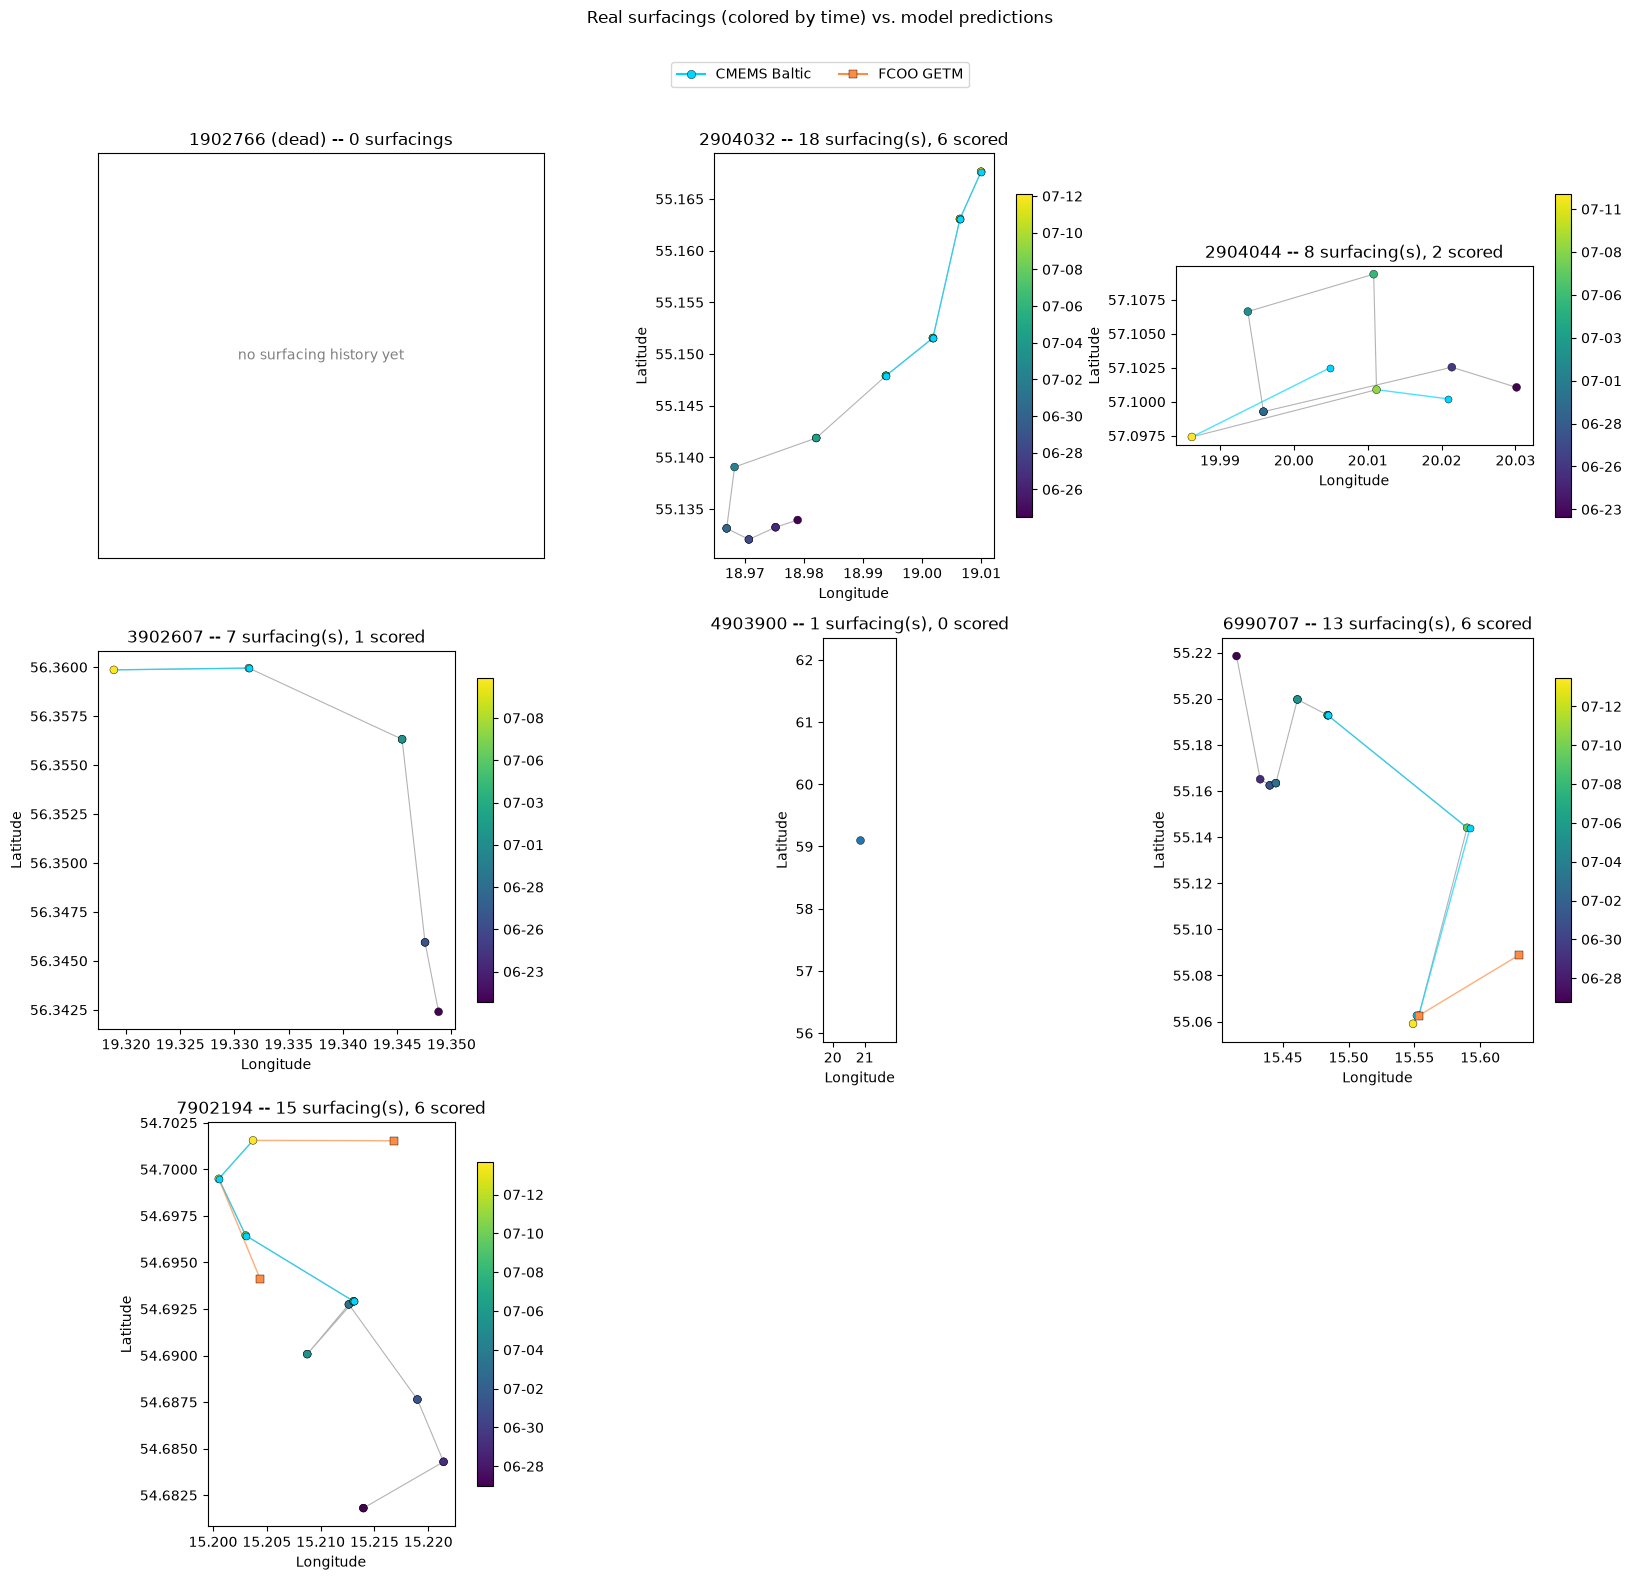

In [7]:
float_ids = sorted(floats_db.keys())
n = len(float_ids)
ncols = 3
nrows = -(-n // ncols)  # ceil

fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 5 * nrows), squeeze=False)

for idx, float_id in enumerate(float_ids):
    ax = axes[idx // ncols][idx % ncols]
    row = floats_db[float_id]

    surf = sorted(row.surfacing_history, key=lambda p: p[2])  # (lat, lon, t)

    if not surf:
        ax.text(0.5, 0.5, "no surfacing history yet", ha="center", va="center",
                transform=ax.transAxes, color="0.5")
        ax.set_xticks([])
        ax.set_yticks([])
        status = " (dead)" if row.is_dead else ""
        ax.set_title(f"{float_id}{status} -- 0 surfacings")
        continue

    lats = [p[0] for p in surf]
    lons = [p[1] for p in surf]
    t_nums = mdates.date2num([p[2] for p in surf])

    ax.plot(lons, lats, "-", color="0.7", linewidth=0.8, zorder=1)
    if len(surf) >= 2:
        sc = ax.scatter(lons, lats, c=t_nums, cmap="viridis", s=32,
                         edgecolors="k", linewidths=0.3, zorder=3)
        cb = fig.colorbar(sc, ax=ax, shrink=0.8)
        cb.ax.yaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    else:
        # A single point has no time range to color by -- plot it plainly
        # rather than let a degenerate (vmin == vmax) colorbar render nonsense.
        ax.scatter(lons, lats, color="tab:blue", s=32, edgecolors="k", linewidths=0.3, zorder=3)

    fscoring = scoring[scoring["float_id"] == float_id]
    for _, r in fscoring.iterrows():
        color = MODEL_COLOR.get(r["model"], "#888888")
        marker = MODEL_MARKER.get(r["model"], "^")
        ax.plot([r["real_lon"], r["predicted_lon"]], [r["real_lat"], r["predicted_lat"]],
                "-", color=color, linewidth=1.0, alpha=0.7, zorder=2)
        ax.scatter([r["predicted_lon"]], [r["predicted_lat"]], color=color, marker=marker,
                    s=26, edgecolors="k", linewidths=0.3, zorder=4)

    mean_lat = np.mean(lats)
    ax.set_aspect(1 / np.cos(np.radians(mean_lat)))
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    status = " (dead)" if row.is_dead else ""
    ax.set_title(f"{float_id}{status} -- {len(surf)} surfacing(s), {len(fscoring)} scored")

# Hide unused grid slots
for idx in range(n, nrows * ncols):
    axes[idx // ncols][idx % ncols].axis("off")

legend_handles = [
    plt.Line2D([0], [0], marker=MODEL_MARKER.get(m, "^"), color=c, linestyle="-",
               markeredgecolor="k", markeredgewidth=0.3, label=web_export.MODEL_DISPLAY.get(m, m))
    for m, c in MODEL_COLOR.items()
]
fig.legend(handles=legend_handles, loc="upper center", ncol=len(legend_handles), bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Real surfacings (colored by time) vs. model predictions", y=1.05)
fig.tight_layout()

## Notes

- A float with only one surfacing on record (e.g. a just-registered float)
  shows a single dot and no path -- not an error, just not enough history
  yet.
- `scoring_history`-equivalent rows only exist from when `errors.parquet`
  started carrying `real_lat`/`predicted_lat` (see
  `web_export._build_scoring_history`'s docstring) -- earlier scored
  surfacings for older floats won't have a prediction line even though
  they were scored, since the real/predicted positions weren't retained at
  the time.
- `fcoo` predictions only appear from when FCOO fetching came online for a
  given float -- floats with only CMEMS lines aren't missing data, FCOO
  just wasn't being scored for them yet at that point in time.